In [1]:
!unzip -q "/content/drive/MyDrive/deep/archive.zip" -d "/content/dataset/"

In [2]:
!pip install thop

In [3]:
import numpy as np
import torch

In [4]:

INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/dataset/UCI-HAR Dataset/"

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    X_signals = np.array(X_signals)
    return np.transpose(X_signals, (1, 2, 0))

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1

In [6]:
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt" for signal in INPUT_SIGNAL_TYPES
]

y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"


X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [7]:
# GPU 사용 가능 여부 확인 for pytorch
device_available = torch.cuda.is_available()
print(f"GPU 사용 가능 여부: {device_available}")

if device_available:
    device_name = torch.cuda.get_device_name(0)
    print(f"사용 중인 GPU 장치: {device_name}")

    device = torch.device("cuda")
    x = torch.tensor([1.0, 2.0]).to(device)
    print(f"텐서가 할당된 장치: {x.device}")
else:
    print("GPU를 인식하지 못했습니다. 설정을 다시 확인해주세요.")
    model = "cpu"

GPU 사용 가능 여부: True
사용 중인 GPU 장치: Tesla T4
텐서가 할당된 장치: cuda:0


In [8]:
import time
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from thop import profile
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

In [9]:
class HAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (B, 9, 128)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
train_dataset = HAR_Dataset(X_train, y_train)
test_dataset  = HAR_Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

X_raw shape = (2947, 1152)


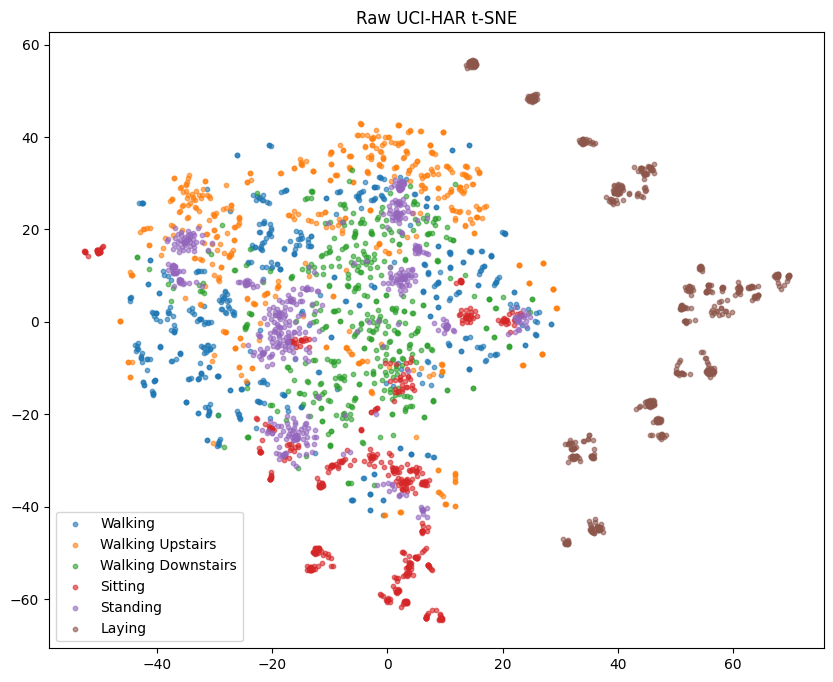

In [11]:
X_raw = X_test.reshape(X_test.shape[0], -1)

print(f"X_raw shape = {X_raw.shape}")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

embedding = tsne.fit_transform(X_raw)

activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

plt.figure(figsize=(10,8))

for i in range(6):
    idx = y_test == i

    plt.scatter(
        embedding[idx,0],
        embedding[idx,1],
        s=10,
        alpha=0.6,
        label=activity_names[i]
    )

plt.legend()
plt.title("Raw UCI-HAR t-SNE")
plt.show()

# **ResNet의 shortcut을 구현해보자**
ResBlock을 구현하기 위해 따로 클래스를 만들어야한다.

In [72]:
class ResBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    if in_channels != out_channels: #shortcut 정의.
      self.shortcut = nn.Sequential(
          nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
          nn.BatchNorm1d(out_channels)
      )
    else:
      self.shortcut = nn.Identity()

    self.layer1 = nn.Conv1d( in_channels, out_channels, kernel_size=5, padding=2 )
    self.bn1 = nn.BatchNorm1d(out_channels)
    self.layer2 = nn.Conv1d( out_channels, out_channels, kernel_size=5, padding=2)
    self.bn2 = nn.BatchNorm1d(out_channels)
    self.relu = nn.ReLU()

  def forward(self, x, return_feature=False):
    shortcut = self.shortcut(x)
    x = self.layer1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.layer2(x)
    x = self.bn2(x)

    x = x + shortcut
    x = self.relu(x)

    return x




In [73]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(9, 64, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(
            ResBlock(64, 64),
            nn.MaxPool1d(2),

            ResBlock(64, 128),
            nn.MaxPool1d(2),

            ResBlock(128, 256),
            nn.MaxPool1d(2),
        )
        self.dropout = nn.Dropout(0.3)

        self.fc = nn.LazyLinear(6)

    def forward(self, x, return_feature=False):

        x = F.relu(self.conv1(x))

        x = self.resblocks(x)

        x = F.adaptive_avg_pool1d(x, 1)
        feat = torch.flatten(x, 1)
        x = self.dropout(feat)
        logits = self.fc(feat)

        if return_feature:
            return logits, feat

        return logits

In [76]:
def train(model, loader):
    model.train()

    total_loss = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds)
            all_labels.append(y)

    return (torch.cat(all_preds).cpu(), torch.cat(all_labels).cpu())

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_profile(model):
  dummy_input = torch.randn(1, 9, 128).to(device)
  flops, params = profile(model, inputs=(dummy_input,))
  return flops, params

def benchmark(model, loader):
  model.eval()
  torch.cuda.synchronize()

  start = time.time()
  with torch.no_grad():
    for x, _ in loader:
      x = x.to(device)
      _ = model(x)

  torch.cuda.synchronize()
  end = time.time()

  return end - start

def extract_features(model, loader):
    model.eval()

    features = []
    labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            _, feat = model(X, return_feature=True)

            features.append(feat.cpu().numpy())
            labels.append(y.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    return features, labels

In [77]:
model = MyModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    loss = train(model, train_loader)

    print(f"Epoch {epoch+1}: loss={loss:.4f}")

Epoch 1: loss=0.1963
Epoch 2: loss=0.1292
Epoch 3: loss=0.1237
Epoch 4: loss=0.1108
Epoch 5: loss=0.1100
Epoch 6: loss=0.1059
Epoch 7: loss=0.1041
Epoch 8: loss=0.1077
Epoch 9: loss=0.1021
Epoch 10: loss=0.0925
Epoch 11: loss=0.0821
Epoch 12: loss=0.0801
Epoch 13: loss=0.0868
Epoch 14: loss=0.0839
Epoch 15: loss=0.0743
Epoch 16: loss=0.0678
Epoch 17: loss=0.0629
Epoch 18: loss=0.0633
Epoch 19: loss=0.0615
Epoch 20: loss=0.0577
Epoch 21: loss=0.0578
Epoch 22: loss=0.0534
Epoch 23: loss=0.0529
Epoch 24: loss=0.0450
Epoch 25: loss=0.0357
Epoch 26: loss=0.0376
Epoch 27: loss=0.0369
Epoch 28: loss=0.0269
Epoch 29: loss=0.0294
Epoch 30: loss=0.0287
Epoch 31: loss=0.0313
Epoch 32: loss=0.0212
Epoch 33: loss=0.0297
Epoch 34: loss=0.0258
Epoch 35: loss=0.0177
Epoch 36: loss=0.0182
Epoch 37: loss=0.0138
Epoch 38: loss=0.0094
Epoch 39: loss=0.0077
Epoch 40: loss=0.0103
Epoch 41: loss=0.0176
Epoch 42: loss=0.0153
Epoch 43: loss=0.0175
Epoch 44: loss=0.0065
Epoch 45: loss=0.0112
Epoch 46: loss=0.00

In [78]:
y_pred, y_true = evaluate(model, test_loader)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print(f"accuracy = {acc}\nprecision = {prec}\nrecall = {rec}\nf1-score = {f1}")

accuracy = 0.9514760773668137
precision = 0.9526172658338701
recall = 0.9514242705945919
f1-score = 0.9508254192774946


In [79]:
model_profile = get_profile(model)
latency = benchmark(model, test_loader)

data = {
    "Model": ["CNN1D"],
    "Params (K)": int(model_profile[1]),
    "FLOPs (M)": model_profile[0],
    "Latency (ms)": latency,
}

df = pd.DataFrame(data)
df

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.


,Model,Params (K),FLOPs (M),Latency (ms)
0,CNN1D,703110,30893568.0,0.111087


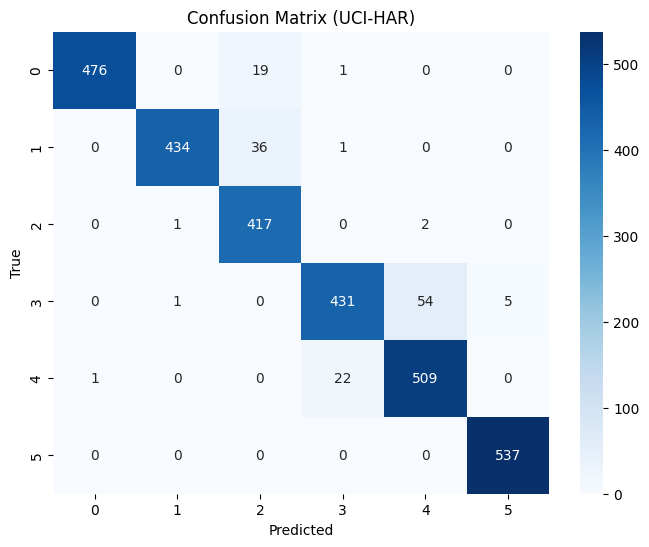

In [80]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (UCI-HAR)")
plt.show()

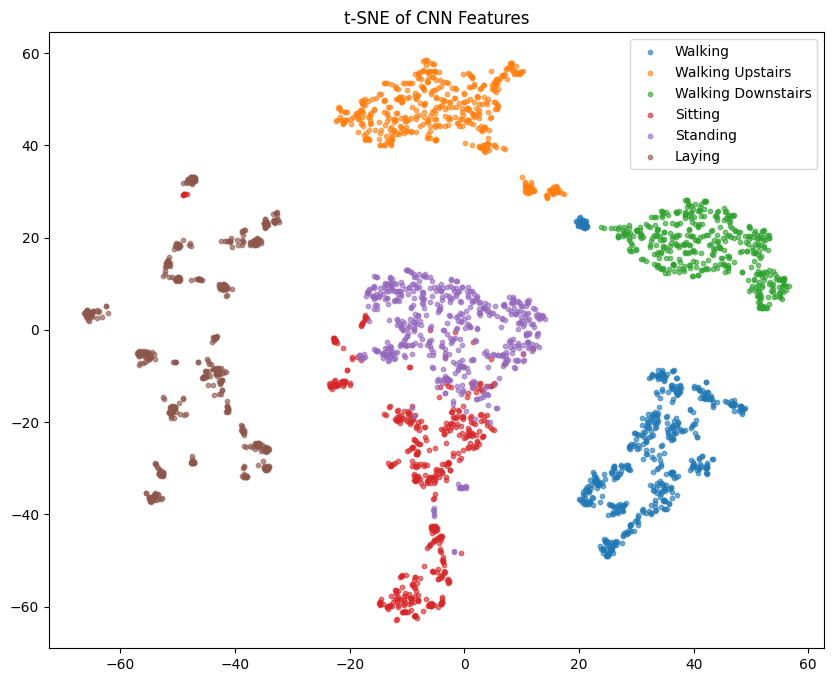

In [81]:
features, labels = extract_features(model, test_loader)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

embedding = tsne.fit_transform(features)


activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

plt.figure(figsize=(10,8))

for i in range(6):
    idx = labels == i

    plt.scatter(
        embedding[idx,0],
        embedding[idx,1],
        label=activity_names[i],
        alpha=0.6,
        s=10
    )

plt.legend()
plt.title("t-SNE of CNN Features")
plt.show()